In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Read data
data = pd.read_csv("DATASET/Plant_Parameters.csv")
target = data['Moisture']
features = data.drop('Moisture', axis=1)

# Encode categorical variable
le = LabelEncoder()
features['Plant Type'] = le.fit_transform(features['Plant Type'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2)

# Scaling data for neural network
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


625/625 [==============================] - 2s 3ms/step
Mean Squared Error (Stacked Model): 11.399764490787572
R-squared (Stacked Model): 0.8143012213318218


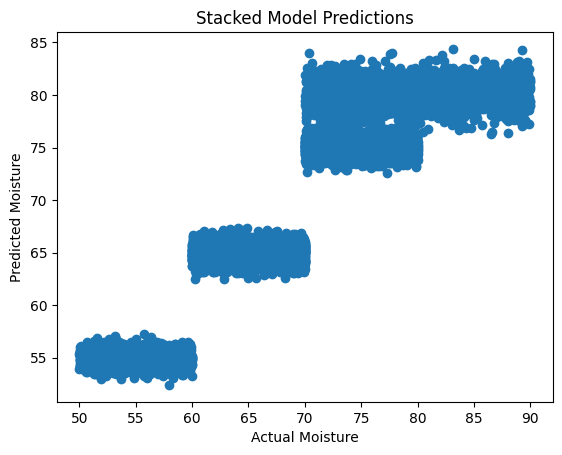

In [2]:

# Base models
base_models = [
    ('gradient_boosting', GradientBoostingRegressor()),
    ('random_forest', RandomForestRegressor()),
    ('decision_tree', DecisionTreeRegressor()),
    ('xgboost', xgb.XGBRegressor(objective='reg:squarederror'))
]

# Adding neural network to base models
base_models.append(('neural_network', None))  # Placeholder for the neural network

# Stacking regression function
def stacking_regression(base_models, meta_model, X_train, y_train, X_test, n_folds=5):
    kf = KFold(n_splits=n_folds)
    meta_features_train = np.zeros((X_train.shape[0], len(base_models)))
    meta_features_test = np.zeros((X_test.shape[0], len(base_models)))
    
    for i, (name, model) in enumerate(base_models):
        if name == 'neural_network':
            # Define the model
            model_nn = Sequential()
            model_nn.add(Dense(256, input_dim=X_train.shape[1], activation='relu'))
            model_nn.add(Dropout(0.5))
            model_nn.add(Dense(128, activation='relu'))
            model_nn.add(Dropout(0.5))
            model_nn.add(Dense(64, activation='relu'))
            model_nn.add(Dropout(0.5))
            model_nn.add(Dense(1, activation='linear'))

            # Compile the model
            model_nn.compile(optimizer='adam', loss='mean_squared_error')

            # Train the model
            model_nn.fit(X_train, y_train, epochs=150, batch_size=32, validation_split=0.2, verbose=0)

            # Use NN predictions as meta features
            meta_features_train[:, i] = model_nn.predict(X_train).flatten()
            meta_features_test[:, i] = model_nn.predict(X_test).flatten()
        else:
            for train_index, val_index in kf.split(X_train):
                X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
                y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
                model.fit(X_train_fold, y_train_fold)
                meta_features_train[val_index, i] = model.predict(X_val_fold)
                meta_features_test[:, i] += model.predict(X_test)
            meta_features_test[:, i] /= n_folds
    
    meta_model.fit(meta_features_train, y_train)
    stacked_predictions = meta_model.predict(meta_features_test)
    
    return stacked_predictions

# Meta-model (Random Forest)
meta_model = RandomForestRegressor()

# Generate stacked predictions
stacked_predictions = stacking_regression(base_models, meta_model, X_train, y_train, X_test)

# Evaluation
mse = mean_squared_error(y_test, stacked_predictions)
r2 = r2_score(y_test, stacked_predictions)

print("Mean Squared Error (Stacked Model):", mse)
print("R-squared (Stacked Model):", r2)

# Optionally plot predictions vs. actual values
plt.figure()
plt.scatter(y_test, stacked_predictions)
plt.xlabel("Actual Moisture")
plt.ylabel("Predicted Moisture")
plt.title("Stacked Model Predictions")
plt.show()